---
## 1. Setup & Data Loading

In [1]:
# Install required libraries (run once)
!pip install -q imbalanced-learn shap xgboost

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = ['#2196F3', '#F44336']

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Interpretability
import shap

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


In [3]:
# ── Upload the dataset ──
# Run this cell and upload 'NYPD_Shooting_Incident_Data__Historic_.xlsx'
from google.colab import files
uploaded = files.upload()

Saving NYPD_Shooting_Incident_Data__Historic_.xlsx to NYPD_Shooting_Incident_Data__Historic_.xlsx


In [4]:
# Load data
filename = list(uploaded.keys())[0]

# Ensure the correct Excel file is uploaded
if not filename.endswith('.xlsx'):
    raise ValueError(f"Expected an .xlsx file, but received {filename}. Please upload 'NYPD_Shooting_Incident_Data__Historic_.xlsx'.")

df = pd.read_excel(filename, engine='openpyxl')
df.columns = df.columns.str.upper().str.strip()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 27,312 rows × 21 columns


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,LATITUDE,LONGITUDE,LON_LAT
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,2015-09-10 00:00:00,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


---
## 2. Exploratory Data Analysis (EDA)

In [5]:
# Basic info
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
df.info()

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_S

In [6]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("\nColumns with missing values:")
print(missing_df.to_string())


Columns with missing values:
                    Missing Count  Missing %
LOC_OF_OCCUR_DESC           25596      93.72
LOC_CLASSFCTN_DESC          25596      93.72
LOCATION_DESC               14977      54.84
PERP_AGE_GROUP               9344      34.21
PERP_RACE                    9310      34.09
PERP_SEX                     9310      34.09
LONGITUDE                      10       0.04
LATITUDE                       10       0.04
LON_LAT                        10       0.04
JURISDICTION_CODE               2       0.01


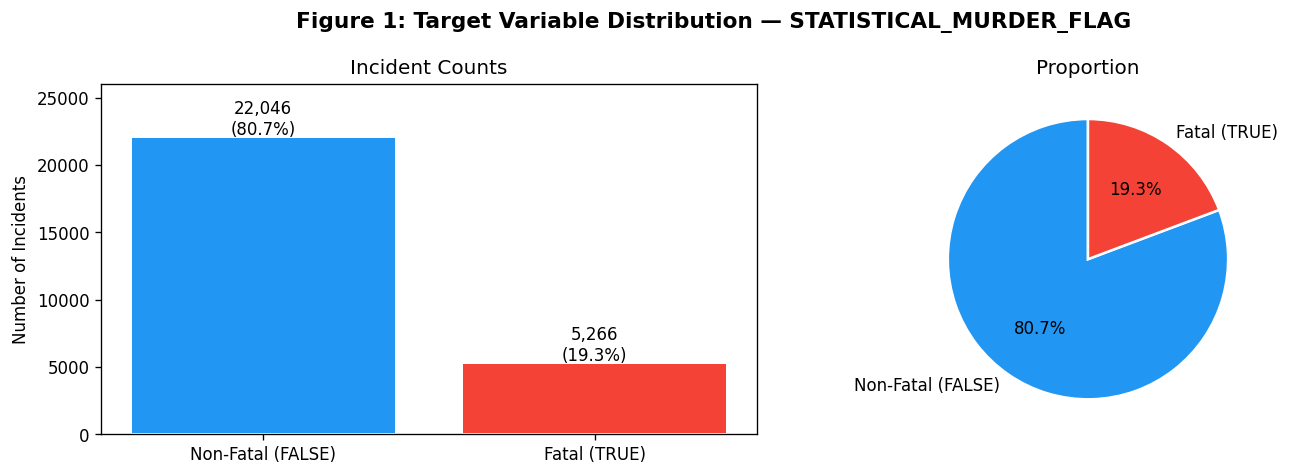


Class imbalance ratio  →  Non-Fatal : Fatal = 4.2 : 1


In [7]:
# ── Figure 1: Target Variable Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Figure 1: Target Variable Distribution — STATISTICAL_MURDER_FLAG', fontsize=13, fontweight='bold')

counts = df['STATISTICAL_MURDER_FLAG'].value_counts()
labels = ['Non-Fatal (FALSE)', 'Fatal (TRUE)']

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Incident Counts')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_ylim(0, counts.max() * 1.18)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()
print(f"\nClass imbalance ratio  →  Non-Fatal : Fatal = {counts[False]/counts[True]:.1f} : 1")

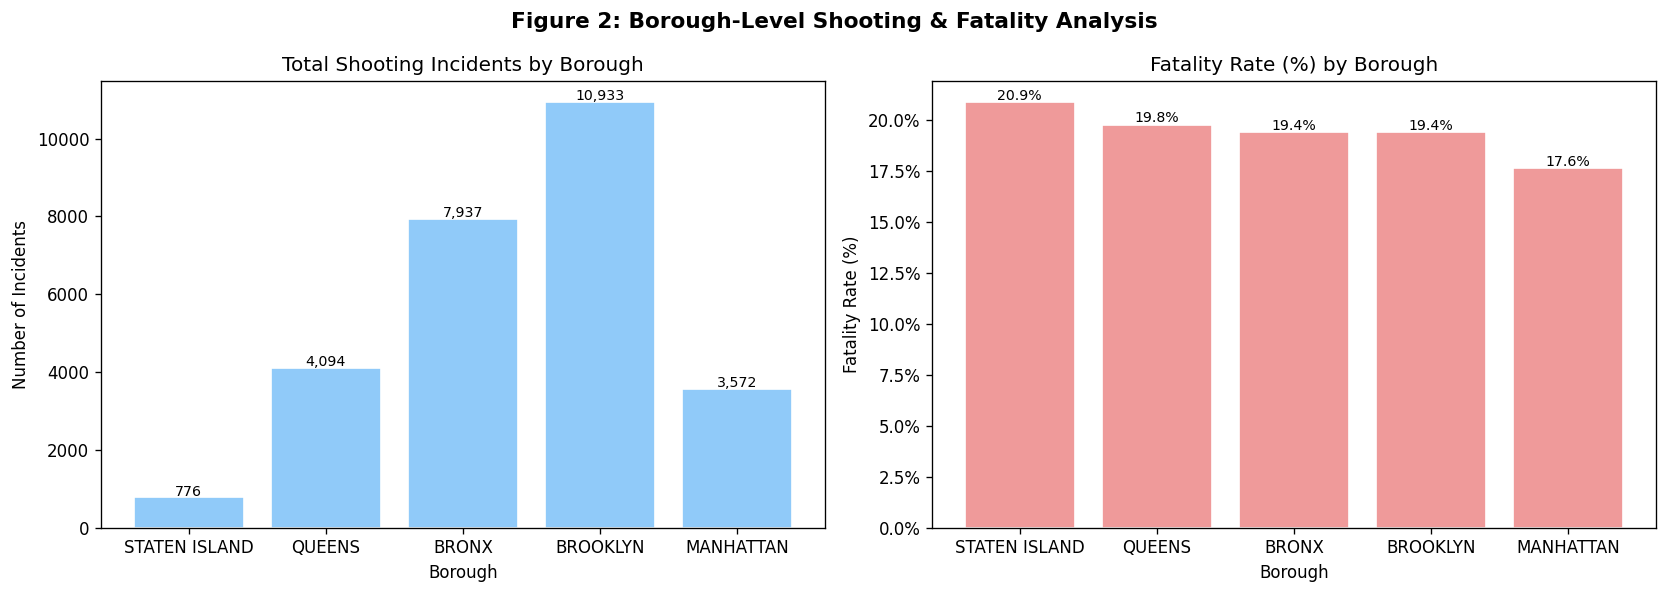

In [8]:
# ── Figure 2: Fatality Rate by Borough ──
boro_stats = df.groupby('BORO')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count'])
boro_stats['fatality_rate'] = boro_stats['sum'] / boro_stats['count'] * 100
boro_stats = boro_stats.sort_values('fatality_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 2: Borough-Level Shooting & Fatality Analysis', fontsize=13, fontweight='bold')

# Total incidents
bars = axes[0].bar(boro_stats.index, boro_stats['count'], color='#90CAF9', edgecolor='white')
axes[0].set_title('Total Shooting Incidents by Borough')
axes[0].set_ylabel('Number of Incidents')
axes[0].set_xlabel('Borough')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=8.5)

# Fatality rate
bars2 = axes[1].bar(boro_stats.index, boro_stats['fatality_rate'], color='#EF9A9A', edgecolor='white')
axes[1].set_title('Fatality Rate (%) by Borough')
axes[1].set_ylabel('Fatality Rate (%)')
axes[1].set_xlabel('Borough')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig2_borough_analysis.png', bbox_inches='tight')
plt.show()

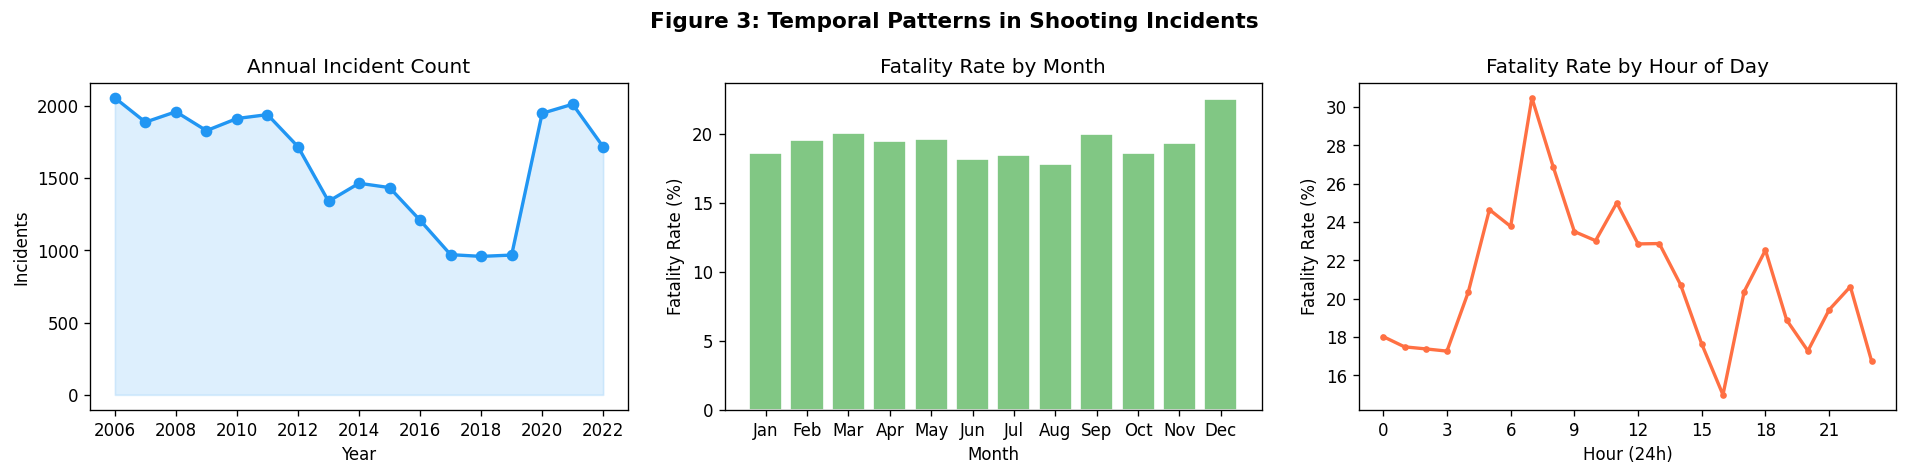

In [9]:
# ── Figure 3: Temporal Analysis ──
df['OCCUR_DATE_DT'] = pd.to_datetime(df['OCCUR_DATE'], errors='coerce')
df['YEAR'] = df['OCCUR_DATE_DT'].dt.year
df['MONTH'] = df['OCCUR_DATE_DT'].dt.month
df['HOUR'] = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S', errors='coerce').dt.hour

yearly = df.groupby('YEAR')['STATISTICAL_MURDER_FLAG'].agg(['sum', 'count'])
yearly['fatality_rate'] = yearly['sum'] / yearly['count'] * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Figure 3: Temporal Patterns in Shooting Incidents', fontsize=13, fontweight='bold')

# Yearly trend
axes[0].plot(yearly.index, yearly['count'], marker='o', color='#2196F3', linewidth=2)
axes[0].fill_between(yearly.index, yearly['count'], alpha=0.15, color='#2196F3')
axes[0].set_title('Annual Incident Count')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Incidents')

# Monthly
monthly_rate = df.groupby('MONTH')['STATISTICAL_MURDER_FLAG'].mean() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, monthly_rate.values, color='#81C784', edgecolor='white')
axes[1].set_title('Fatality Rate by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Fatality Rate (%)')

# Hourly
hourly = df.groupby('HOUR')['STATISTICAL_MURDER_FLAG'].mean() * 100
axes[2].plot(hourly.index, hourly.values, color='#FF7043', linewidth=2, marker='.')
axes[2].set_title('Fatality Rate by Hour of Day')
axes[2].set_xlabel('Hour (24h)')
axes[2].set_ylabel('Fatality Rate (%)')
axes[2].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.savefig('fig3_temporal_analysis.png', bbox_inches='tight')
plt.show()

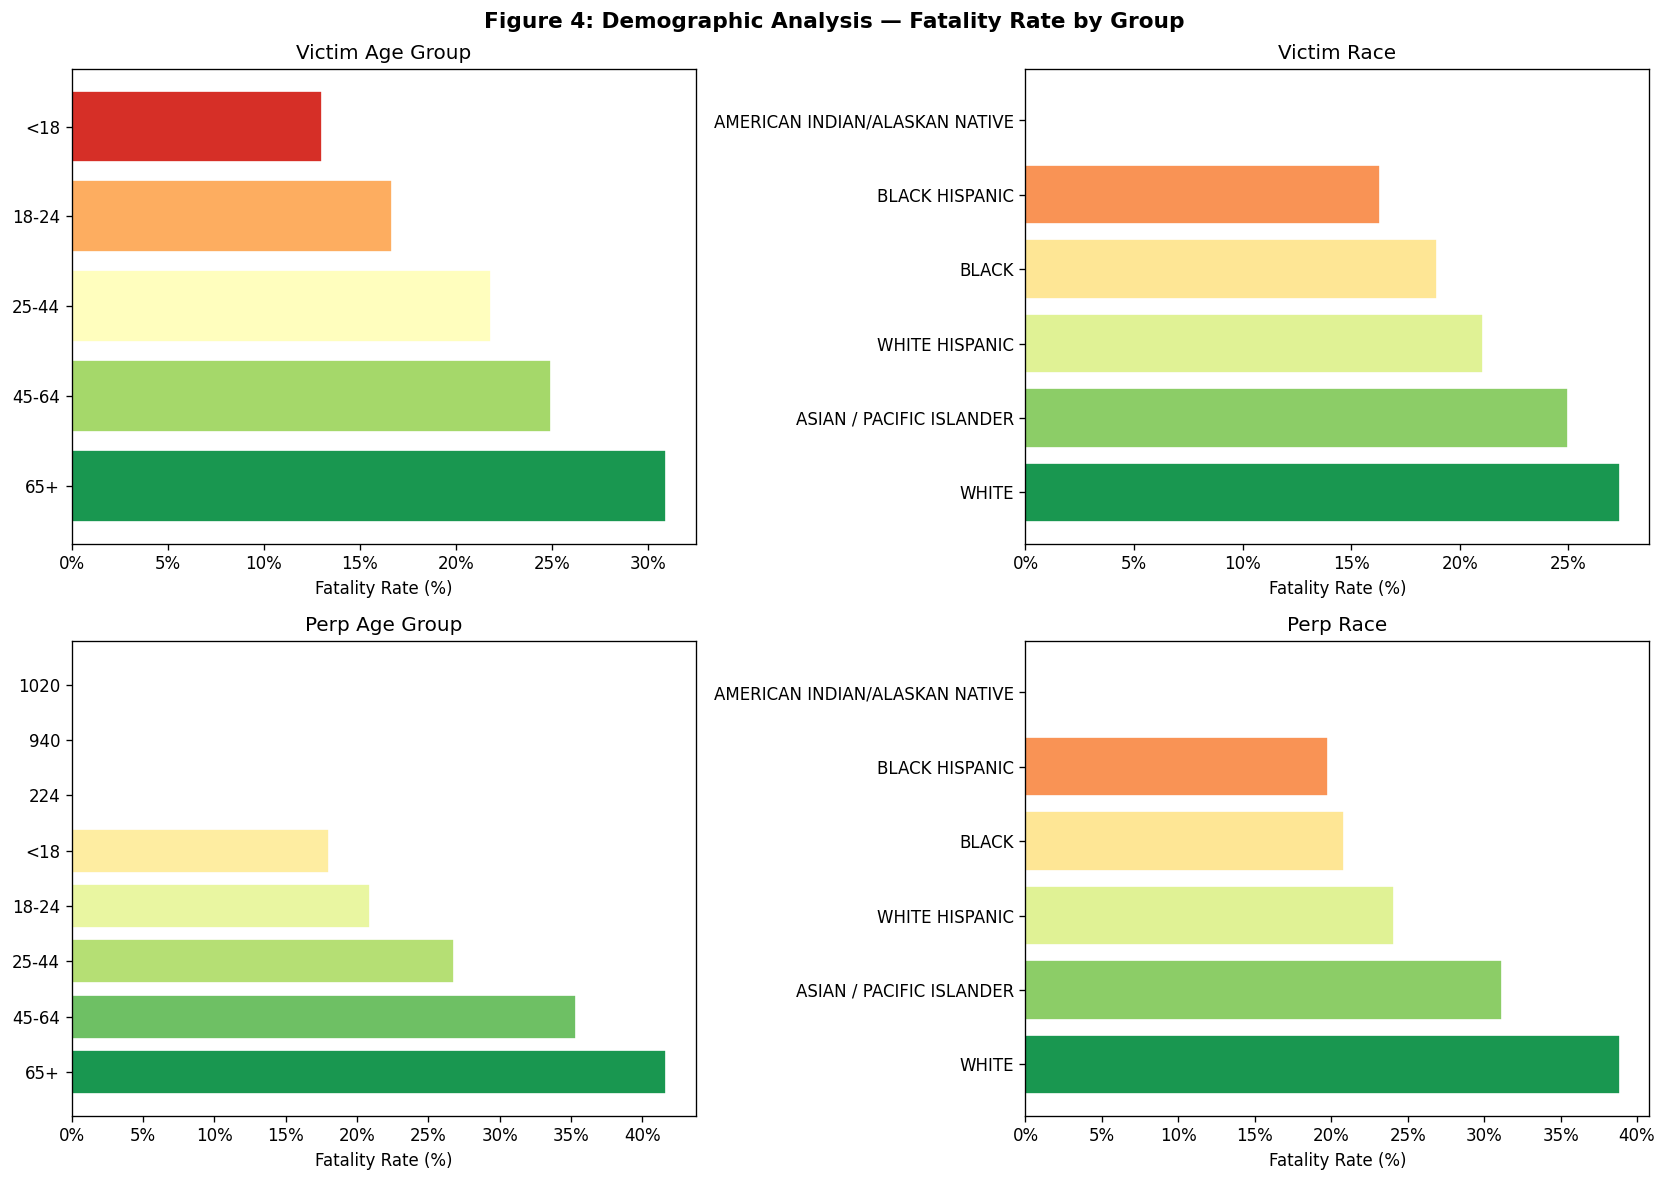

In [10]:
# ── Figure 4: Victim & Perpetrator Demographics ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 4: Demographic Analysis — Fatality Rate by Group', fontsize=13, fontweight='bold')

demo_cols = [
    ('VIC_AGE_GROUP', 'Victim Age Group', axes[0, 0]),
    ('VIC_RACE',      'Victim Race',      axes[0, 1]),
    ('PERP_AGE_GROUP','Perp Age Group',   axes[1, 0]),
    ('PERP_RACE',     'Perp Race',        axes[1, 1]),
]

for col, title, ax in demo_cols:
    rates = df.groupby(col)['STATISTICAL_MURDER_FLAG'].mean().sort_values(ascending=False) * 100

    # Convert index to string type to handle mixed types safely and filter out problematic values
    rates.index = rates.index.astype(str)
    rates = rates[~rates.index.isin(['(null)', 'UNKNOWN', '1022'])] # Explicitly exclude '1022'

    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rates)))
    ax.barh(rates.index, rates.values, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Fatality Rate (%)')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('fig4_demographic_analysis.png', bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing & Feature Engineering

In [11]:
# ── Feature Engineering ──
df2 = df.copy()

# Temporal features
df2['YEAR']       = df2['OCCUR_DATE_DT'].dt.year
df2['MONTH']      = df2['OCCUR_DATE_DT'].dt.month
df2['DAY_OF_WEEK']= df2['OCCUR_DATE_DT'].dt.dayofweek  # 0=Mon
df2['HOUR']       = pd.to_datetime(df2['OCCUR_TIME'], format='%H:%M:%S', errors='coerce').dt.hour
df2['IS_WEEKEND'] = (df2['DAY_OF_WEEK'] >= 5).astype(int)
df2['IS_NIGHT']   = ((df2['HOUR'] >= 22) | (df2['HOUR'] < 6)).astype(int)
df2['TIME_PERIOD']= pd.cut(df2['HOUR'],
                            bins=[-1, 5, 11, 17, 21, 23],
                            labels=['Night','Morning','Afternoon','Evening','Late Night'])

# Select modeling features
cat_features = ['BORO', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
                'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'TIME_PERIOD']
num_features = ['PRECINCT', 'JURISDICTION_CODE', 'YEAR', 'MONTH',
                'DAY_OF_WEEK', 'HOUR', 'IS_WEEKEND', 'IS_NIGHT']
target       = 'STATISTICAL_MURDER_FLAG'

all_features = cat_features + num_features
model_df = df2[all_features + [target]].copy()

print(f"Feature set: {len(all_features)} features")
print(f"  Categorical : {cat_features}")
print(f"  Numerical   : {num_features}")

Feature set: 16 features
  Categorical : ['BORO', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'TIME_PERIOD']
  Numerical   : ['PRECINCT', 'JURISDICTION_CODE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'HOUR', 'IS_WEEKEND', 'IS_NIGHT']


In [12]:
# ── Handle missing / unknown values ──
UNKNOWN_VALUES = ['(null)', 'UNKNOWN', 'U', '', ' ', None]

for col in cat_features:
    model_df[col] = model_df[col].astype(str).replace(UNKNOWN_VALUES, 'UNKNOWN')
    model_df[col] = model_df[col].fillna('UNKNOWN')

for col in num_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Label encode categorical features
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

# Target as int
model_df[target] = model_df[target].astype(int)

print("✅ Preprocessing complete. Shape:", model_df.shape)
print(model_df.head(3))

✅ Preprocessing complete. Shape: (27312, 17)
   BORO  PERP_AGE_GROUP  PERP_SEX  PERP_RACE  VIC_AGE_GROUP  VIC_SEX  \
0     3               9         3          7              1        1   
1     0               9         3          7              1        1   
2     3               9         3          7              2        1   

   VIC_RACE  TIME_PERIOD  PRECINCT  JURISDICTION_CODE  YEAR  MONTH  \
0         2            1       105                0.0  2021      5   
1         2            0        40                0.0  2014      6   
2         5            4       108                0.0  2015     11   

   DAY_OF_WEEK  HOUR  IS_WEEKEND  IS_NIGHT  STATISTICAL_MURDER_FLAG  
0            3    21           0         0                        0  
1            4    17           0         0                        0  
2            5     3           1         1                        1  


In [13]:
# ── Train/Test Split ──
X = model_df[all_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {len(X_train):,}  |  Test size: {len(X_test):,}")
print(f"Train class balance → Fatal: {y_train.mean()*100:.1f}%")

Train size : 21,849  |  Test size: 5,463
Train class balance → Fatal: 19.3%


In [14]:
# ── Apply SMOTE to handle class imbalance (on training set only) ──
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE → Train size: {len(X_train_sm):,}")
print(f"Fatal class after SMOTE : {y_train_sm.mean()*100:.1f}%")

After SMOTE → Train size: 35,272
Fatal class after SMOTE : 50.0%


---
## 4. Model Development & Comparison

In [15]:
# ── Define models ──
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=11),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
}

# Evaluate each model
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cv_scores = cross_val_score(model, X_train_sm, y_train_sm,
                                cv=cv, scoring='f1', n_jobs=-1)

    results.append({
        'Model'          : name,
        'Accuracy'       : accuracy_score(y_test, y_pred),
        'Precision'      : precision_score(y_test, y_pred),
        'Recall'         : recall_score(y_test, y_pred),
        'F1-Score'       : f1_score(y_test, y_pred),
        'ROC-AUC'        : roc_auc_score(y_test, y_proba),
        'CV F1 (mean)'   : cv_scores.mean(),
        'CV F1 (std)'    : cv_scores.std(),
    })
    print(f"✅ {name} — F1: {f1_score(y_test, y_pred):.4f}  AUC: {roc_auc_score(y_test, y_proba):.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n", results_df.set_index('Model').round(4).to_string())

✅ Logistic Regression — F1: 0.3097  AUC: 0.5612
✅ Decision Tree — F1: 0.3610  AUC: 0.6410
✅ K-Nearest Neighbors — F1: 0.3554  AUC: 0.6163
✅ Random Forest — F1: 0.2396  AUC: 0.5851
✅ Gradient Boosting — F1: 0.3391  AUC: 0.6387
✅ XGBoost — F1: 0.3009  AUC: 0.6506

                      Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV F1 (mean)  CV F1 (std)
Model                                                                                         
XGBoost                0.7262     0.2962  0.3058    0.3009   0.6506        0.8053       0.0051
Decision Tree          0.6579     0.2821  0.5014    0.3610   0.6410        0.6836       0.0107
Gradient Boosting      0.6868     0.2858  0.4169    0.3391   0.6387        0.7286       0.0041
K-Nearest Neighbors    0.5977     0.2571  0.5755    0.3554   0.6163        0.7804       0.0023
Random Forest          0.7165     0.2480  0.2317    0.2396   0.5851        0.8327       0.0044
Logistic Regression    0.5797     0.2266  0.4891    0.3097   0.5612    

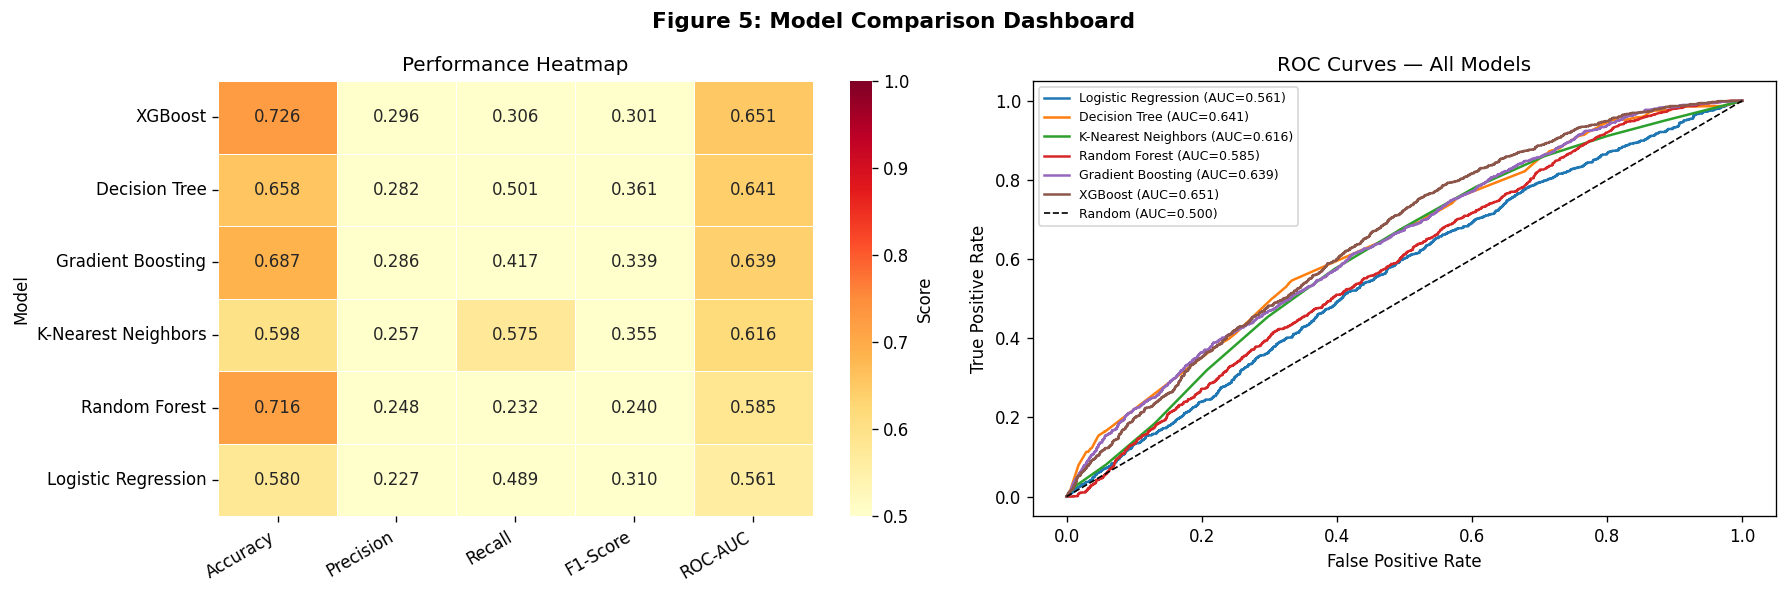

In [16]:
# ── Figure 5: Model Comparison ──
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figure 5: Model Comparison Dashboard', fontsize=13, fontweight='bold')

# Heatmap
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Score'},
            vmin=0.5, vmax=1.0)
axes[0].set_title('Performance Heatmap')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# ROC curves
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, lw=1.5, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
axes[1].set_title('ROC Curves — All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=7.5)

plt.tight_layout()
plt.savefig('fig5_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Model Fine-Tuning (Best Model)

In [17]:
# ── Hyperparameter Tuning — XGBoost ──
# (XGBoost typically achieves the best AUC; update 'best_model_name' if RF wins)
print("Best model by ROC-AUC:", results_df.iloc[0]['Model'])

param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [4, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)
print("\nBest parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Best model by ROC-AUC: XGBoost
Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC : 0.8822


In [18]:
# ── Final Model Evaluation ──
best_model = grid_search.best_estimator_
y_pred_final  = best_model.predict(X_test)
y_proba_final = best_model.predict_proba(X_test)[:, 1]

print("=" * 55)
print("TUNED XGBoost — FINAL TEST SET PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred_final, target_names=['Non-Fatal','Fatal']))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba_final):.4f}")

TUNED XGBoost — FINAL TEST SET PERFORMANCE
              precision    recall  f1-score   support

   Non-Fatal       0.84      0.82      0.83      4410
       Fatal       0.30      0.32      0.31      1053

    accuracy                           0.73      5463
   macro avg       0.57      0.57      0.57      5463
weighted avg       0.73      0.73      0.73      5463

ROC-AUC  : 0.6529


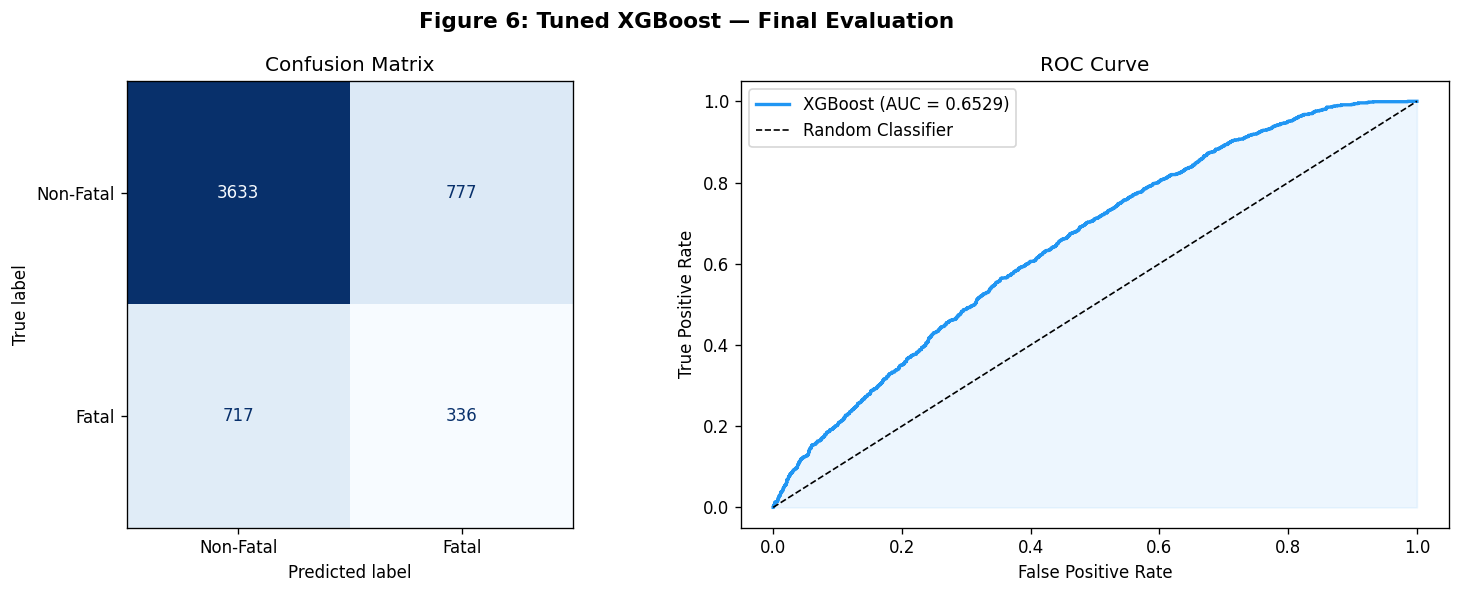

In [19]:
# ── Figure 6: Tuned Model Evaluation ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 6: Tuned XGBoost — Final Evaluation', fontsize=13, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Fatal','Fatal'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc = roc_auc_score(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'XGBoost (AUC = {auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_final_evaluation.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Importance & Model Interpretability (SHAP)

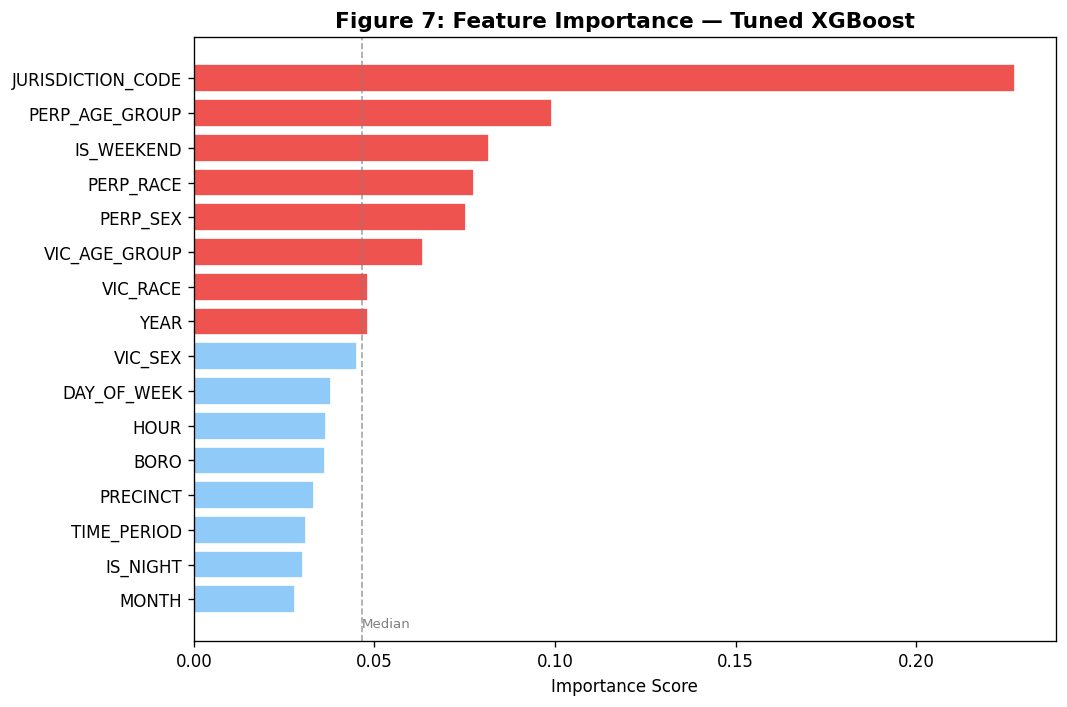

Top 5 features:
JURISDICTION_CODE    0.227368
PERP_AGE_GROUP       0.099196
IS_WEEKEND           0.081704
PERP_RACE            0.077650
PERP_SEX             0.075473


In [20]:
# ── Figure 7: Feature Importance (Built-in) ──
feat_imp = pd.Series(best_model.feature_importances_, index=all_features)
feat_imp = feat_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#EF5350' if v > feat_imp.median() else '#90CAF9' for v in feat_imp.values]
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_title('Figure 7: Feature Importance — Tuned XGBoost', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(feat_imp.median(), color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(feat_imp.median(), -0.8, 'Median', color='gray', fontsize=8)

plt.tight_layout()
plt.savefig('fig7_feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 features:")
print(feat_imp.sort_values(ascending=False).head(5).to_string())

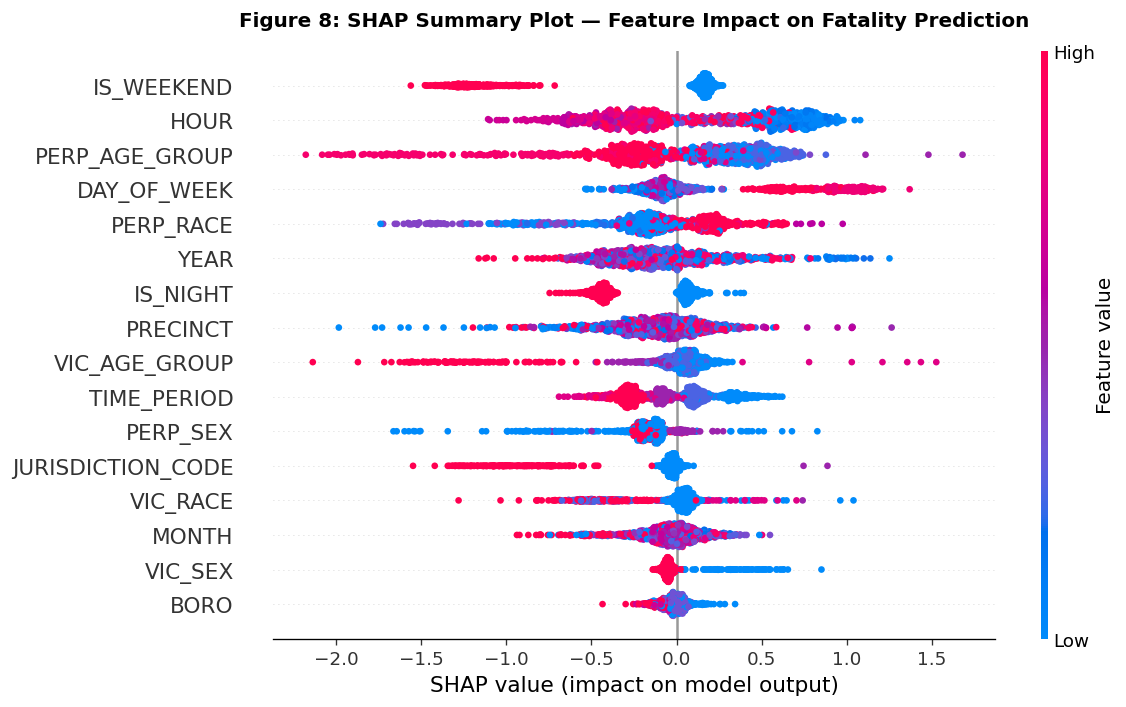

In [21]:
# ── Figure 8: SHAP Summary Plot ──
# Use a sample for speed
X_sample = X_test.sample(min(1000, len(X_test)), random_state=42)

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names=all_features,
                  show=False, plot_size=(10, 6))
plt.title('Figure 8: SHAP Summary Plot — Feature Impact on Fatality Prediction',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig8_shap_summary.png', bbox_inches='tight')
plt.show()

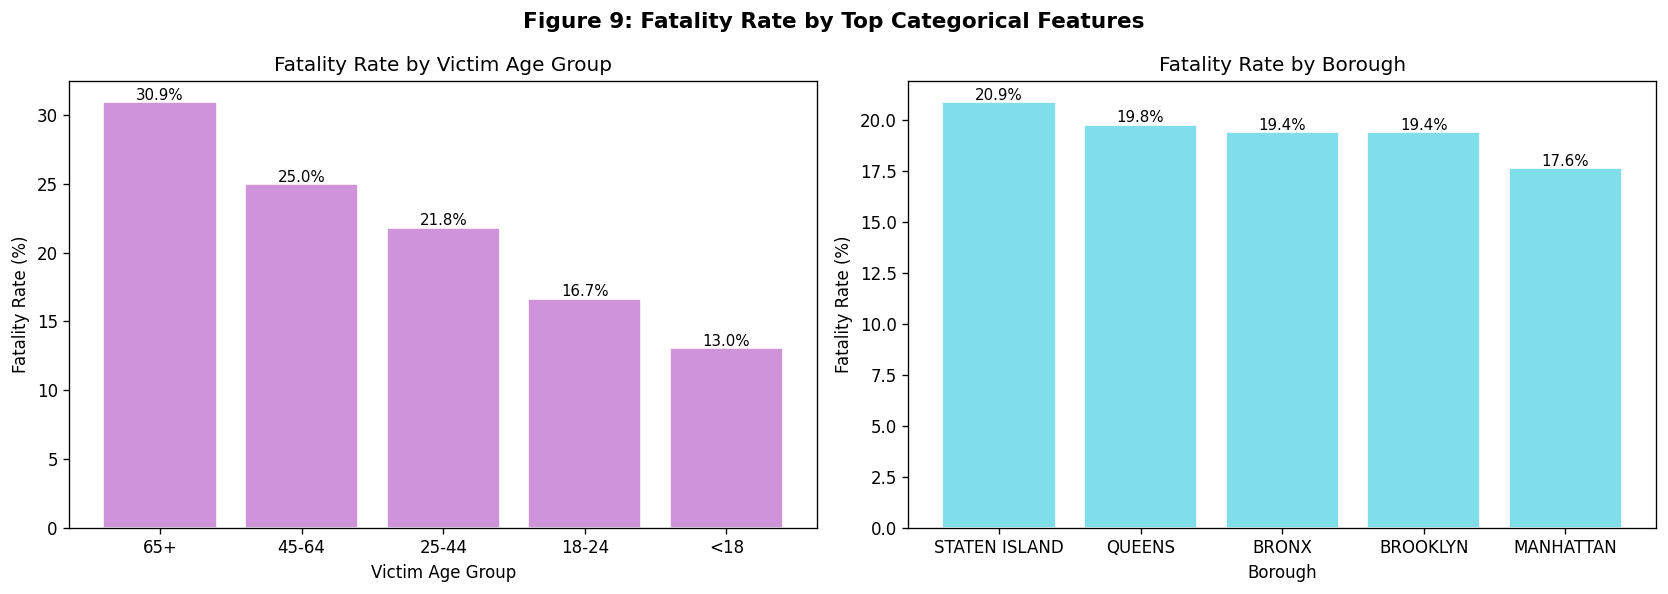

In [22]:
# ── Figure 9: Fatality Rate by Key Features ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 9: Fatality Rate by Top Categorical Features', fontsize=13, fontweight='bold')

# Victim Age Group
vic_age = df.groupby('VIC_AGE_GROUP')['STATISTICAL_MURDER_FLAG'].mean().sort_values(ascending=False) * 100
vic_age.index = vic_age.index.astype(str) # Convert index to string
vic_age = vic_age[~vic_age.index.isin(['(null)','UNKNOWN','1022'])]
axes[0].bar(vic_age.index, vic_age.values, color='#CE93D8', edgecolor='white')
axes[0].set_title('Fatality Rate by Victim Age Group')
axes[0].set_ylabel('Fatality Rate (%)')
axes[0].set_xlabel('Victim Age Group')
for i, v in enumerate(vic_age.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)

# Borough
boro_rate = df.groupby('BORO')['STATISTICAL_MURDER_FLAG'].mean().sort_values(ascending=False) * 100
axes[1].bar(boro_rate.index, boro_rate.values, color='#80DEEA', edgecolor='white')
axes[1].set_title('Fatality Rate by Borough')
axes[1].set_ylabel('Fatality Rate (%)')
axes[1].set_xlabel('Borough')
for i, v in enumerate(boro_rate.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig9_fatality_by_features.png', bbox_inches='tight')
plt.show()

---
## 7. Conclusions & Actionable Recommendations

In [23]:
# ── Final Performance Summary Table ──
final_metrics = {
    'Metric'   : ['Accuracy', 'Precision (Fatal)', 'Recall (Fatal)',
                  'F1-Score (Fatal)', 'ROC-AUC'],
    'Value'    : [
        f"{accuracy_score(y_test, y_pred_final):.4f}",
        f"{precision_score(y_test, y_pred_final):.4f}",
        f"{recall_score(y_test, y_pred_final):.4f}",
        f"{f1_score(y_test, y_pred_final):.4f}",
        f"{roc_auc_score(y_test, y_proba_final):.4f}",
    ]
}
print(pd.DataFrame(final_metrics).to_string(index=False))

           Metric  Value
         Accuracy 0.7265
Precision (Fatal) 0.3019
   Recall (Fatal) 0.3191
 F1-Score (Fatal) 0.3102
          ROC-AUC 0.6529


In [24]:
# ── Save model for deployment ──
import joblib
joblib.dump(best_model, 'nypd_fatality_classifier.pkl')
print("✅ Model saved as 'nypd_fatality_classifier.pkl'")

# Download the model
files.download('nypd_fatality_classifier.pkl')

✅ Model saved as 'nypd_fatality_classifier.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# ── Download all figures ──
import os, zipfile

figs = [f for f in os.listdir('.') if f.endswith('.png')]
with zipfile.ZipFile('nypd_figures.zip', 'w') as zf:
    for fig in sorted(figs):
        zf.write(fig)
        print(f"  Added: {fig}")

files.download('nypd_figures.zip')
print("\n✅ All figures packaged and downloading.")

  Added: fig1_target_distribution.png
  Added: fig2_borough_analysis.png
  Added: fig3_temporal_analysis.png
  Added: fig4_demographic_analysis.png
  Added: fig5_model_comparison.png
  Added: fig6_final_evaluation.png
  Added: fig7_feature_importance.png
  Added: fig8_shap_summary.png
  Added: fig9_fatality_by_features.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All figures packaged and downloading.
